# Transmission Spectrum Fitting

This notebook demonstrates the Levenberg-Marquardt fitting engine: given a
measured transmission spectrum, recover the areal density of each isotope.

## Approach

1. Generate synthetic "measured" data using `forward_model()` with a known density
2. Add Gaussian noise to simulate experimental uncertainty
3. Fit with `spatial_map_typed()` (wrapping the 1D spectrum as a 1x1 pixel image) to recover the density
4. Analyze fit quality: residuals, chi-squared, uncertainty estimates
5. Retrieve sample temperature via `fit_temperature=True`
6. Fit with resolution broadening to demonstrate unbiased recovery

## Note on the 1D→3D pattern

The old `fit_spectrum()` function accepted 1D arrays directly. It has been
replaced by the typed pipeline: wrap 1D data as a `(n_e, 1, 1)` cube,
create an `InputData` object via `from_transmission()`, then call
`spatial_map_typed()`. This is a few extra lines but uses the same
optimised code path as full spatial mapping.

```python
T_3d = T_1d[:, None, None].copy()
sigma_3d = sigma_1d[:, None, None].copy()
data = nereids.from_transmission(T_3d, sigma_3d)
result = nereids.spatial_map_typed(data, energies, [isotope], ...)
density = result.density_maps[0][0, 0]
```

In [ ]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)  # reproducibility


def fit_spectrum_1d(T_1d, sigma_1d, energies, isotopes, **kwargs):
    """Convenience wrapper: fit a single 1D spectrum via the typed API.

    Wraps the 1D arrays as a (n_e, 1, 1) cube, calls spatial_map_typed,
    and returns a simple namespace with the familiar scalar results.
    """
    T_3d = np.ascontiguousarray(T_1d[:, None, None])
    sigma_3d = np.ascontiguousarray(sigma_1d[:, None, None])
    data = nereids.from_transmission(T_3d, sigma_3d)
    result = nereids.spatial_map_typed(data, energies, isotopes, **kwargs)

    class _Result:
        pass

    r = _Result()
    r.densities = [m[0, 0] for m in result.density_maps]
    r.uncertainties = [m[0, 0] for m in result.uncertainty_maps]
    r.reduced_chi_squared = float(np.array(result.chi_squared_map)[0, 0])
    r.converged = bool(np.array(result.converged_map)[0, 0])
    # Iteration count is not exposed per-pixel; use n_converged as proxy
    r.iterations = result.n_converged  # 1 if converged, 0 if not
    # Temperature (if fit_temperature=True)
    if result.temperature_map is not None:
        r.temperature_k = float(np.array(result.temperature_map)[0, 0])
        # Temperature uncertainty is not directly available from SpatialResult;
        # report NaN as a placeholder.
        r.temperature_k_unc = float('nan')
    return r

In [2]:
# U-238 resonance data
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Energy grid: fine spacing around the resonance
E_core = np.linspace(6.674 - 0.5, 6.674 + 0.5, 500)
E_wings_low = np.linspace(1.0, 6.674 - 0.5, 100)[:-1]
E_wings_high = np.linspace(6.674 + 0.5, 15.0, 100)[1:]
energies = np.sort(np.concatenate([E_wings_low, E_core, E_wings_high]))

print(f"Energy grid: {len(energies)} points")

Energy grid: 698 points


## 1. Generate Synthetic Measurement

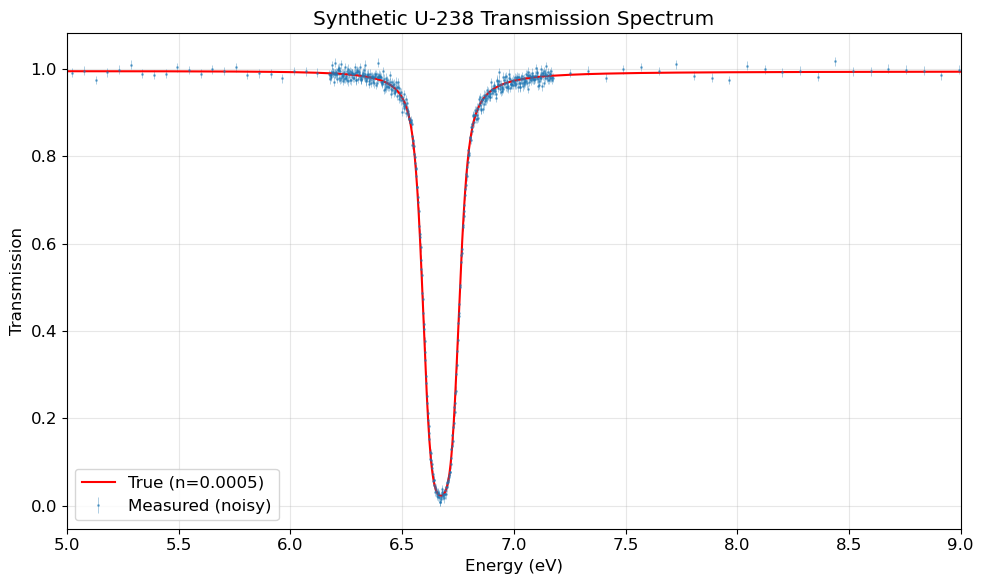

In [3]:
# True parameters
true_density = 5e-4  # atoms/barn
temperature = 300.0  # K
noise_level = 0.01   # Gaussian sigma on transmission

# Generate true transmission (no resolution broadening — matches fit model)
T_true = np.asarray(nereids.forward_model(
    energies, [(u238, true_density)], temperature_k=temperature
))

# Add Gaussian noise
noise = np.random.normal(0, noise_level, len(energies))
T_measured = T_true + noise
sigma = np.full_like(T_measured, noise_level)

fig, ax = plt.subplots()
ax.errorbar(energies, T_measured, yerr=sigma, fmt='.', markersize=2,
            alpha=0.5, label='Measured (noisy)', elinewidth=0.5)
ax.plot(energies, T_true, 'r-', linewidth=1.5, label=f'True (n={true_density})')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Synthetic U-238 Transmission Spectrum')
ax.legend()
ax.set_xlim(5, 9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fit the Spectrum

In [ ]:
result = fit_spectrum_1d(
    T_measured, sigma, energies,
    [u238],
    temperature_k=temperature,
    initial_densities=[1e-3],  # initial guess
    max_iter=100
)

fitted_density = result.densities[0]
fitted_unc = result.uncertainties[0]
rel_error = abs(fitted_density - true_density) / true_density * 100

print(f"True density:    {true_density:.6f} atoms/barn")
print(f"Fitted density:  {fitted_density:.6f} ± {fitted_unc:.6f} atoms/barn")
print(f"Relative error:  {rel_error:.2f}%")
print(f"Reduced χ²:      {result.reduced_chi_squared:.4f}")
print(f"Converged:       {result.converged}")

assert result.converged, "Fit did not converge!"
assert rel_error < 5, f"Relative error {rel_error:.1f}% exceeds 5% threshold"
print("\nFit quality check passed!")

## 3. Fit Result Visualization

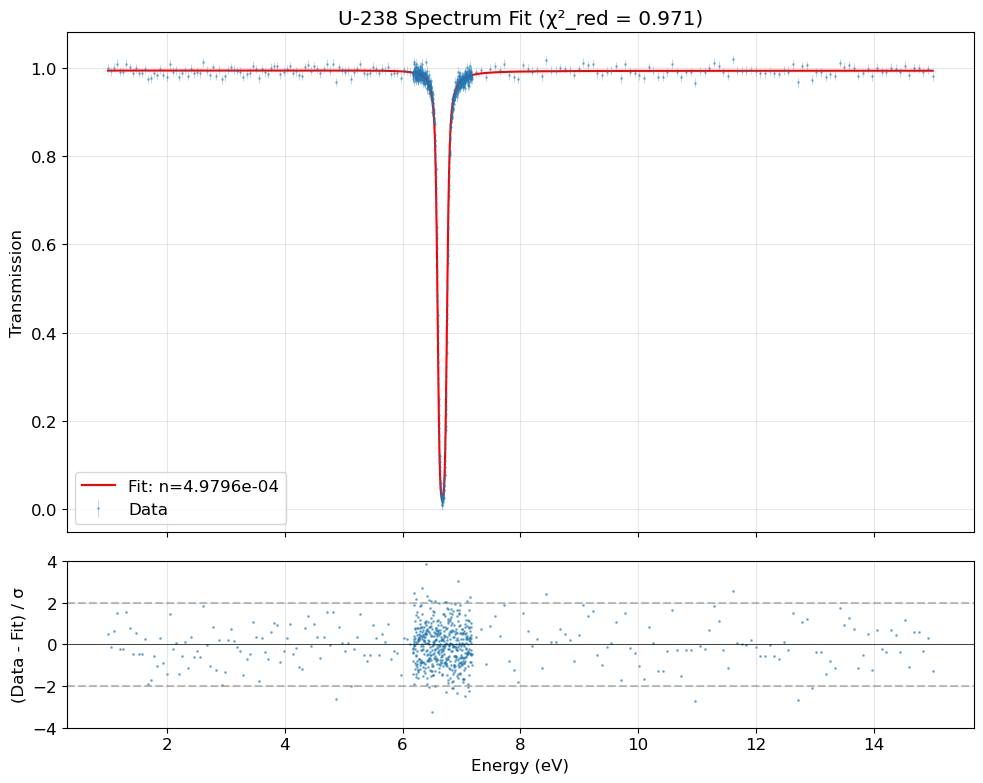

In [5]:
# Compute the fitted model
T_fitted = np.asarray(nereids.forward_model(
    energies, [(u238, fitted_density)], temperature_k=temperature
))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top: data + fit
ax = axes[0]
ax.errorbar(energies, T_measured, yerr=sigma, fmt='.', markersize=2,
            alpha=0.4, label='Data', elinewidth=0.5, color='C0')
ax.plot(energies, T_fitted, 'r-', linewidth=1.5,
        label=f'Fit: n={fitted_density:.4e}')
ax.set_ylabel('Transmission')
ax.set_title(f'U-238 Spectrum Fit (χ²_red = {result.reduced_chi_squared:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom: standardized residuals
ax = axes[1]
residuals = (T_measured - T_fitted) / sigma
ax.scatter(energies, residuals, s=1, alpha=0.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(2, color='gray', linestyle='--', alpha=0.5)
ax.axhline(-2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('(Data - Fit) / σ')
ax.set_ylim(-4, 4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

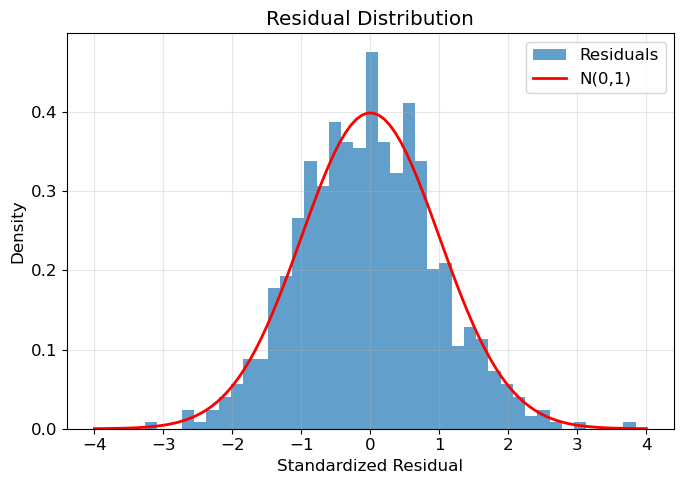

Residual mean: -0.0351 (expected: 0)
Residual std:  0.9840 (expected: 1)


In [6]:
# Residual distribution: should be approximately N(0,1)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=40, density=True, alpha=0.7, label='Residuals')

# Overlay standard normal
x = np.linspace(-4, 4, 100)
ax.plot(x, np.exp(-x**2/2) / np.sqrt(2*np.pi), 'r-', linewidth=2, label='N(0,1)')

ax.set_xlabel('Standardized Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Residual mean: {np.mean(residuals):.4f} (expected: 0)")
print(f"Residual std:  {np.std(residuals):.4f} (expected: 1)")

## 4. Initial Guess Sensitivity

A good optimizer should converge from a wide range of starting points.

In [ ]:
initial_guesses = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

print(f"{'Initial Guess':>14} {'Fitted':>12} {'Rel Error':>10} {'χ²_red':>8} {'Conv':>6}")
print("-" * 60)

for guess in initial_guesses:
    r = fit_spectrum_1d(
        T_measured, sigma, energies, [u238],
        temperature_k=temperature,
        initial_densities=[guess],
        max_iter=200
    )
    rel_err = abs(r.densities[0] - true_density) / true_density * 100
    print(f"{guess:>14.1e} {r.densities[0]:>12.6f} {rel_err:>9.2f}% {r.reduced_chi_squared:>8.4f} {str(r.converged):>6}")

## 5. Effect of Noise Level on Uncertainty

In [ ]:
noise_levels = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
fitted_densities = []
fitted_uncertainties = []

for sigma_noise in noise_levels:
    noise = np.random.normal(0, sigma_noise, len(energies))
    T_noisy = T_true + noise
    s = np.full_like(T_noisy, sigma_noise)

    r = fit_spectrum_1d(
        T_noisy, s, energies, [u238],
        temperature_k=temperature,
        initial_densities=[1e-3],
        max_iter=200
    )
    fitted_densities.append(r.densities[0])
    fitted_uncertainties.append(r.uncertainties[0])

fitted_densities = np.array(fitted_densities)
fitted_uncertainties = np.array(fitted_uncertainties)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: fitted density vs noise level
ax = axes[0]
ax.errorbar(noise_levels, fitted_densities, yerr=fitted_uncertainties,
            fmt='o-', capsize=4)
ax.axhline(true_density, color='r', linestyle='--', label=f'True = {true_density}')
ax.set_xlabel('Noise Level (σ)')
ax.set_ylabel('Fitted Density (atoms/barn)')
ax.set_title('Fitted Density vs Noise Level')
ax.legend()
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Right: uncertainty vs noise level
ax = axes[1]
ax.loglog(noise_levels, fitted_uncertainties, 'o-')
ax.set_xlabel('Noise Level (σ)')
ax.set_ylabel('Fitted Uncertainty')
ax.set_title('Parameter Uncertainty vs Noise Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Wrong Model Test

When the model is mis-specified (e.g., wrong temperature), the fit should show χ² >> 1.

In [ ]:
# Data was generated at 300K. Fit with different temperatures.
test_temps = [0, 100, 200, 300, 500, 1000]

print(f"{'Fit Temp (K)':>12} {'Density':>12} {'χ²_red':>10} {'Conv':>6}")
print("-" * 44)

for T_fit in test_temps:
    r = fit_spectrum_1d(
        T_measured, sigma, energies, [u238],
        temperature_k=float(T_fit),
        initial_densities=[1e-3],
        max_iter=200
    )
    marker = " ← correct" if T_fit == 300 else ""
    print(f"{T_fit:>12} {r.densities[0]:>12.6f} {r.reduced_chi_squared:>10.4f} {str(r.converged):>6}{marker}")

print("\nNote: χ²_red ≈ 1.0 only when the model temperature matches the data.")

## 7. Temperature Retrieval

`spatial_map_typed()` can treat `temperature_k` as a **free parameter** alongside
the areal densities by setting `fit_temperature=True`.  The optimizer then
recovers both the density and the Doppler temperature in a single fit, with
propagated uncertainties for each.

This is a key VENUS experiment requirement: determine sample temperature (or the
temperature of the scattering environment) from the resonance lineshapes.

**Approach**:
1. Generate data at an elevated temperature (e.g. 500 K).
2. Call the fitting pipeline with `fit_temperature=True` and an intentionally wrong
   initial temperature guess.
3. Verify that the optimizer recovers the true temperature and density.
4. Cross-validate against the old chi-squared grid-search method.

In [ ]:
TRUE_TEMP = 500.0   # K — elevated temperature for clear Doppler effect
np.random.seed(99)

# Generate data at 500 K
T_hot = np.asarray(nereids.forward_model(
    energies, [(u238, true_density)], temperature_k=TRUE_TEMP
))
T_hot_measured = T_hot + np.random.normal(0, noise_level, len(energies))
sigma_hot = np.full_like(T_hot_measured, noise_level)

# ── Direct fit with fit_temperature=True ──
result_temp = fit_spectrum_1d(
    T_hot_measured, sigma_hot, energies, [u238],
    temperature_k=200.0,        # intentionally wrong initial guess
    fit_temperature=True,
    max_iter=200,
)

print("=== Direct Temperature Fit ===")
print(f"True temperature:  {TRUE_TEMP:.1f} K")
print(f"Fitted temperature:{result_temp.temperature_k:.1f} K")
print(f"True density:      {true_density:.6f} atoms/barn")
print(f"Fitted density:    {result_temp.densities[0]:.6f} ± {result_temp.uncertainties[0]:.6f} atoms/barn")
print(f"Reduced chi2:      {result_temp.reduced_chi_squared:.4f}")
print(f"Converged:         {result_temp.converged}")

T_error = abs(result_temp.temperature_k - TRUE_TEMP)
n_error = abs(result_temp.densities[0] - true_density) / true_density * 100
assert result_temp.converged, "Temperature fit did not converge!"
assert T_error < 50, f"Temperature error {T_error:.1f} K exceeds 50 K threshold"
assert n_error < 5, f"Density error {n_error:.1f}% exceeds 5% threshold"
print("\nDirect fit quality check passed!")

# ── Cross-validation: chi-squared grid search ──
T_grid = np.arange(50, 1001, 25, dtype=float)
chi2_grid = np.empty_like(T_grid)

for i, T_cand in enumerate(T_grid):
    r = fit_spectrum_1d(
        T_hot_measured, sigma_hot, energies, [u238],
        temperature_k=T_cand, max_iter=100
    )
    chi2_grid[i] = r.reduced_chi_squared

best_idx = int(np.argmin(chi2_grid))
best_T = T_grid[best_idx]

# Parabolic refinement
if 0 < best_idx < len(T_grid) - 1:
    Ta, Tb, Tc = T_grid[best_idx - 1: best_idx + 2]
    ca, cb, cc = chi2_grid[best_idx - 1: best_idx + 2]
    denom = 2*cc - 4*cb + 2*ca
    refined_T = Tb - 0.5 * (Tc - Ta) * (cc - ca) / denom if abs(denom) > 1e-12 else Tb
else:
    refined_T = best_T

print(f"\n=== Grid-Search Cross-Validation ===")
print(f"Grid minimum:      {best_T:.1f} K")
print(f"Parabolic refined: {refined_T:.1f} K")

# ── Plot: direct fit vs grid search ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: chi2 profile from grid search
ax = axes[0]
ax.plot(T_grid, chi2_grid, "o-", markersize=3, linewidth=1.2, color="C0", label="Grid search chi2_red(T)")
ax.axvline(TRUE_TEMP, color="r", linestyle="--", linewidth=1.5, label=f"True T = {TRUE_TEMP:.0f} K")
ax.axvline(result_temp.temperature_k, color="g", linestyle="-", linewidth=2,
           label=f"fit_temperature=True: {result_temp.temperature_k:.1f} K")
ax.axvline(refined_T, color="C1", linestyle=":", linewidth=1.5,
           label=f"Grid refined: {refined_T:.1f} K")
ax.axhline(1.0, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Reduced chi-squared")
ax.set_title("Temperature Recovery: Direct Fit vs Grid Search")
ax.legend(fontsize=9)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

# Right: fitted spectrum at recovered temperature
T_fitted_temp = np.asarray(nereids.forward_model(
    energies, [(u238, result_temp.densities[0])],
    temperature_k=result_temp.temperature_k
))
ax = axes[1]
ax.errorbar(energies, T_hot_measured, yerr=sigma_hot, fmt=".", markersize=2,
            alpha=0.3, label="Data (T=500 K)", elinewidth=0.5, color="C0")
ax.plot(energies, T_fitted_temp, "r-", linewidth=1.5,
        label=f"Fit: n={result_temp.densities[0]:.4e}, T={result_temp.temperature_k:.1f} K")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Transmission")
ax.set_title("Spectrum Fit with Free Temperature")
ax.set_xlim(5, 9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAgreement: direct fit T = {result_temp.temperature_k:.1f} K, "
      f"grid refined T = {refined_T:.1f} K  "
      f"(difference: {abs(result_temp.temperature_k - refined_T):.1f} K)")

## 8. Fitting with Resolution Broadening

Real neutron instruments have finite energy resolution. When the measured data includes resolution effects, the fitting model must account for them — otherwise the recovered density is systematically biased.

The fitting pipeline supports resolution broadening via Gaussian instrument parameters (`flight_path_m`, `delta_t_us`, `delta_l_m`) or a tabulated resolution function (`resolution=`).

In [ ]:
# VENUS-like instrument parameters
flight_path = 25.0   # meters
delta_t = 5.0        # μs timing uncertainty
delta_l = 0.01       # m path length uncertainty

# Generate data WITH resolution broadening (simulates real measurement)
T_with_res = np.asarray(nereids.forward_model(
    energies, [(u238, true_density)], temperature_k=temperature,
    flight_path_m=flight_path, delta_t_us=delta_t, delta_l_m=delta_l
))

# Add noise
noise_res = np.random.normal(0, noise_level, len(energies))
T_measured_res = T_with_res + noise_res

# Fit WITH matching resolution parameters → unbiased
result_res = fit_spectrum_1d(
    T_measured_res, sigma, energies, [u238],
    temperature_k=temperature,
    flight_path_m=flight_path, delta_t_us=delta_t, delta_l_m=delta_l
)

# Fit WITHOUT resolution → biased
result_no_res = fit_spectrum_1d(
    T_measured_res, sigma, energies, [u238],
    temperature_k=temperature
)

print("Fitting resolution-broadened data:")
print(f"  True density:         {true_density:.6f} atoms/barn")
print(f"  With resolution:      {result_res.densities[0]:.6f} ± {result_res.uncertainties[0]:.6f}  "
      f"(error: {abs(result_res.densities[0] - true_density)/true_density*100:.2f}%,  χ²_red = {result_res.reduced_chi_squared:.3f})")
print(f"  Without resolution:   {result_no_res.densities[0]:.6f} ± {result_no_res.uncertainties[0]:.6f}  "
      f"(error: {abs(result_no_res.densities[0] - true_density)/true_density*100:.2f}%,  χ²_red = {result_no_res.reduced_chi_squared:.3f})")

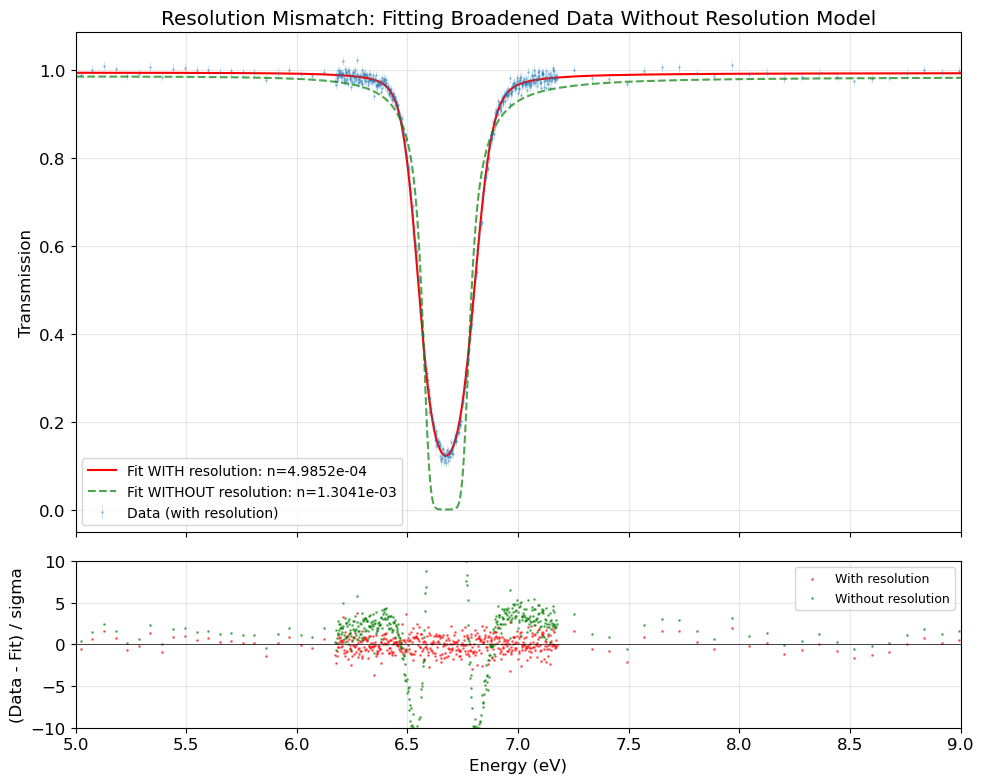

Residual std (with resolution):    1.03 (expected ~1)
Residual std (without resolution): 6.04 (systematic bias)


In [12]:
# Visualize the resolution mismatch
T_fitted_res = np.asarray(nereids.forward_model(
    energies, [(u238, result_res.densities[0])], temperature_k=temperature,
    flight_path_m=flight_path, delta_t_us=delta_t, delta_l_m=delta_l
))
T_fitted_no_res = np.asarray(nereids.forward_model(
    energies, [(u238, result_no_res.densities[0])], temperature_k=temperature
))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

ax = axes[0]
ax.errorbar(energies, T_measured_res, yerr=sigma, fmt=".", markersize=2,
            alpha=0.3, label="Data (with resolution)", elinewidth=0.5, color="C0")
ax.plot(energies, T_fitted_res, "r-", linewidth=1.5,
        label=f"Fit WITH resolution: n={result_res.densities[0]:.4e}")
ax.plot(energies, T_fitted_no_res, "g--", linewidth=1.5, alpha=0.7,
        label=f"Fit WITHOUT resolution: n={result_no_res.densities[0]:.4e}")
ax.set_ylabel("Transmission")
ax.set_title("Resolution Mismatch: Fitting Broadened Data Without Resolution Model")
ax.legend(fontsize=10)
ax.set_xlim(5, 9)
ax.grid(True, alpha=0.3)

ax = axes[1]
resid_with    = (T_measured_res - T_fitted_res) / sigma
resid_without = (T_measured_res - T_fitted_no_res) / sigma
ax.scatter(energies, resid_with,    s=1, alpha=0.5, label="With resolution",    color="r")
ax.scatter(energies, resid_without, s=1, alpha=0.5, label="Without resolution", color="g")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("(Data - Fit) / sigma")
ax.set_ylim(-10, 10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual std (with resolution):    {np.std(resid_with):.2f} (expected ~1)")
print(f"Residual std (without resolution): {np.std(resid_without):.2f} (systematic bias)")


## Summary

In this notebook we demonstrated:

1. **Synthetic data generation**: `forward_model()` + Gaussian noise
2. **Levenberg-Marquardt fitting**: the typed API (`from_transmission` + `spatial_map_typed`) recovers the true areal density
3. **Fit quality**: residuals are N(0,1), reduced chi-squared ~ 1.0
4. **Initial guess robustness**: convergence from a wide range of starting points
5. **Noise scaling**: uncertainty scales linearly with noise level
6. **Model mis-specification**: wrong temperature gives chi-squared >> 1
7. **Temperature retrieval**: `spatial_map_typed(..., fit_temperature=True)` recovers
   the sample temperature as a free parameter alongside density, with propagated
   uncertainty — replacing the manual chi-squared grid search.
   A grid-search cross-validation confirms that both methods agree.
8. **Resolution broadening**: the fitting pipeline supports Gaussian instrument
   resolution via `flight_path_m`, `delta_t_us`, `delta_l_m` parameters.
   Fitting broadened data without resolution in the model causes systematic bias.

### 1D fitting pattern

```python
# Wrap 1D spectrum as (n_e, 1, 1) cube
T_3d = T_1d[:, None, None].copy()
sigma_3d = sigma_1d[:, None, None].copy()
data = nereids.from_transmission(T_3d, sigma_3d)
result = nereids.spatial_map_typed(data, energies, [isotope], temperature_k=300.0)
density = result.density_maps[0][0, 0]
```

For tabulated (Monte Carlo) resolution functions, see
[05_custom_resolution.ipynb](05_custom_resolution.ipynb).

**Next**: [04_multi_isotope_fitting.ipynb](04_multi_isotope_fitting.ipynb) — fitting multiple isotopes simultaneously.